<a href="https://colab.research.google.com/github/Harshit10880/Chat-logger/blob/main/customer_chrun_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction: Classification Model Analysis

## 1. Introduction

This document outlines the process and results of developing various machine learning models to predict customer churn. The goal is to identify customers who are likely to churn based on their demographic and service usage data.

### Dataset Overview
The dataset contains information about customers, including their services, account information, and whether they churned or not.

## 2. Data Preprocessing and Feature Engineering

### Initial Data Inspection and Cleaning
- The `customerID` column was identified as a unique identifier and excluded from analysis.
- The `TotalCharges` column, initially of type `object`, was converted to `numeric` with `errors='coerce'` to handle non-numeric values, and then `NaN` values were dropped.
- `gender`, `Partner`, `Dependents`, and `Churn` columns were label encoded to numerical representations for model training.
- Numerical features (`tenure`, `MonthlyCharges`, `TotalCharges`) were scaled using `StandardScaler` to normalize their ranges.

### Features Used for Classification
After preprocessing, the following features were used for training classification models:
- `tenure` (scaled)
- `TotalCharges` (scaled)
- `SeniorCitizen`
- `MonthlyCharges` (scaled)
- `Dependents` (encoded)
- `Partner` (encoded)

The target variable is `Churn` (0 for No, 1 for Yes).

### Data Splitting
The preprocessed data was split into training and testing sets with an 80/20 ratio, using `stratify=y` to maintain the proportion of churned/non-churned customers in both sets.

## 3. Classification Model Performance

### 3.1 Logistic Regression

#### Initial Model Performance
- **Accuracy**: 0.78
- **Classification Report**:
    ```
                  precision    recall  f1-score   support

               0       0.82      0.90      0.85      1033
               1       0.61      0.44      0.51       374

        accuracy                           0.78      1407
       macro avg       0.71      0.67      0.68      1407
    weighted avg       0.76      0.78      0.76      1407
    ```

#### Hyperparameter Tuning (RandomizedSearchCV)
- **Best Parameters**: `{'solver': 'liblinear', 'penalty': 'l1', 'max_iter': 200, 'C': 0.01}`
- **Best Cross-Validation Score**: 0.7927

#### Tuned Model Performance
- **Accuracy**: 0.779
- **Classification Report**:
    ```
                  precision    recall  f1-score   support

               0       0.81      0.91      0.86      1033
               1       0.63      0.40      0.49       374

        accuracy                           0.78      1407
       macro avg       0.72      0.66      0.68      1407
    weighted avg       0.76      0.78      0.76      1407
    ```

#### Cross-Validation
- **Cross-Validation Scores**: `[0.796, 0.786, 0.780, 0.792, 0.790]`
- **Mean Cross-Validation Score**: 0.789

### 3.2 K-Nearest Neighbors (KNN)

#### Initial Model Performance
- **Accuracy**: 0.75


In [ ]:
# To get the correct classification report for the untuned KNN model's prediction

In [ ]:
model_knn = KNeighborsClassifier()
model_knn.fit(X_train, y_train)
predit_knn = model_knn.predict(X_test)
print("KNN Initial Model Classification Report:")
print(classification_report(y_test, predit_knn))

KNN Initial Model Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.86      0.84      1033
           1       0.54      0.45      0.49       374

    accuracy                           0.75      1407
   macro avg       0.68      0.66      0.66      1407
weighted avg       0.74      0.75      0.74      1407



#### Hyperparameter Tuning (GridSearchCV)
- **Best Parameters**: `{'metric': 'manhattan', 'n_neighbors': 9, 'p': 1, 'weights': 'uniform'}`
- **Best Cross-Validation Score**: 0.7842


In [ ]:
# Recalculate tuned KNN performance using best estimator from GridSearchCV
model_knn_tuned = KNeighborsClassifier(metric='manhattan', n_neighbors=9, p=1, weights='uniform')
model_knn_tuned.fit(X_train, y_train)
predit_knn_tuned = model_knn_tuned.predict(X_test)
print(f"Tuned KNN Model Accuracy: {accuracy_score(y_test, predit_knn_tuned):.2f}")
print("Tuned KNN Model Classification Report:")
print(classification_report(y_test, predit_knn_tuned))

Tuned KNN Model Accuracy: 0.77
Tuned KNN Model Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1033
           1       0.57      0.47      0.51       374

    accuracy                           0.77      1407
   macro avg       0.70      0.67      0.68      1407
weighted avg       0.75      0.77      0.76      1407



#### Cross-Validation
- **Cross-Validation Scores**: `[0.765, 0.769, 0.764, 0.779, 0.766]`
- **Mean Cross-Validation Score**: 0.7691

### 3.3 Naive Bayes (GaussianNB)

#### Initial Model Performance
- **Accuracy**: 0.74


In [ ]:
# To get the correct classification report for the untuned Naive Bayes model's prediction
model_nb = GaussianNB()
model_nb.fit(X_train, y_train)
predt_nb = model_nb.predict(X_test)
print("Naive Bayes Initial Model Classification Report:")
print(classification_report(y_test, predt_nb))

Naive Bayes Initial Model Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.80      0.82      1033
           1       0.52      0.58      0.55       374

    accuracy                           0.74      1407
   macro avg       0.68      0.69      0.69      1407
weighted avg       0.76      0.74      0.75      1407



#### Hyperparameter Tuning
No explicit hyperparameter tuning was performed for the Naive Bayes model in the notebook.

### 3.4 Decision Tree

#### Initial Model Performance
- **Accuracy**: 0.70
- **Classification Report**:
    ```
                  precision    recall  f1-score   support

               0       0.80      0.79      0.79      1033
               1       0.43      0.44      0.44       374

        accuracy                           0.70      1407
       macro avg       0.61      0.62      0.61      1407
    weighted avg       0.70      0.70      0.70      1407
    ```

#### Hyperparameter Tuning (GridSearchCV)
- **Best Parameters**: `{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}`
- **Best Cross-Validation Score**: 0.7886


In [ ]:
# Recalculate tuned Decision Tree performance using best estimator from GridSearchCV
model_dt_tuned = tree.DecisionTreeClassifier(criterion='gini', max_depth=5, min_samples_leaf=1, min_samples_split=2, splitter='best')
model_dt_tuned.fit(X_train, y_train)
predt_dt_tuned = model_dt_tuned.predict(X_test)
print(f"Tuned Decision Tree Model Accuracy: {accuracy_score(y_test, predt_dt_tuned):.2f}")
print("Tuned Decision Tree Model Classification Report:")
print(classification_report(y_test, predt_dt_tuned))

Tuned Decision Tree Model Accuracy: 0.78
Tuned Decision Tree Model Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1033
           1       0.61      0.45      0.52       374

    accuracy                           0.78      1407
   macro avg       0.71      0.67      0.69      1407
weighted avg       0.76      0.78      0.77      1407



### 3.5 Support Vector Machine (SVM)

#### Initial Model Performance
- **Accuracy**: 0.78
- **Classification Report**:
    ```
                  precision    recall  f1-score   support

               0       0.81      0.92      0.86      1033
               1       0.63      0.39      0.48       374

        accuracy                           0.78      1407
       macro avg       0.72      0.65      0.67      1407
    weighted avg       0.76      0.78      0.76      1407
    ```

#### Hyperparameter Tuning (RandomizedSearchCV)
- **Best Parameters**: `{'kernel': 'rbf', 'gamma': 'scale', 'C': 323.745754281764}`
- **Best Cross-Validation Score**: 0.7973

#### Tuned Model Performance
- **Accuracy**: 0.7754
- **Classification Report**:
    ```
                  precision    recall  f1-score   support

               0       0.81      0.90      0.85      1033
               1       0.61      0.43      0.50       374

        accuracy                           0.78      1407
       macro avg       0.71      0.67      0.68      1407
    weighted avg       0.76      0.78      0.76      1407
    ```

### 3.6 Refined Logistic Regression (with additional features)

This model was trained with a slightly different set of features: `gender`, `TotalCharges`, `SeniorCitizen`, `MonthlyCharges`, `Contract` (one-hot encoded), and `tenure`.

- **Accuracy**: 0.78
- **Classification Report**:
    ```
                  precision    recall  f1-score   support

               0       0.82      0.90      0.86      1033
               1       0.62      0.43      0.51       374

        accuracy                           0.78      1407
       macro avg       0.72      0.67      0.68      1407
    weighted avg       0.77      0.78      0.77      1407
    ```

## 4. Conclusion and Recommendations

Based on the analysis, several classification models were evaluated for customer churn prediction. The models generally achieved accuracies around 75-79%.

- **Logistic Regression** and **SVM** showed the best cross-validation scores after tuning (0.7927 and 0.7973 respectively), indicating good generalization performance.
- The **Refined Logistic Regression** also showed competitive performance with an accuracy of 0.78, suggesting that including the one-hot encoded `Contract` feature could be beneficial.
- While Decision Tree and KNN improved with tuning, their overall performance (especially recall for the churn class) was not as strong as Logistic Regression or SVM.

**Next Steps:**
- Further investigation into feature importance for the best performing models.
- Exploring more advanced ensemble methods (e.g., RandomForest, Gradient Boosting) which often yield higher performance in classification tasks.
- Addressing class imbalance more explicitly, as the recall for the churned (positive) class is generally lower across all models, indicating difficulty in correctly identifying churners.

## 5. Regression Model Analysis (Predicting Monthly Charges)

This section details the performance of various regression models trained to predict `MonthlyCharges` based on other features.

### 5.1 Linear Regression

#### Model Performance
- **Mean Absolute Error (MAE)**: 12.21
- **Mean Squared Error (MSE)**: 234.63
- **Root Mean Squared Error (RMSE)**: 15.32
- **R2 Score**: 0.74

The Linear Regression model explains approximately 74% of the variance in `MonthlyCharges`, indicating a reasonably good fit.

### 5.2 Ridge Regression

#### Model Performance
- **Mean Absolute Error (MAE)**: 12.21
- **Mean Squared Error (MSE)**: 234.63
- **Root Mean Squared Error (RMSE)**: 15.32
- **R2 Score**: 0.74

Ridge Regression, a regularized version of Linear Regression, yielded very similar performance metrics to the standard Linear Regression model, suggesting that multicollinearity might not be a significant issue or that the regularization strength is not heavily penalizing the coefficients for this dataset.

### 5.3 K-Nearest Neighbors (KNN) Regression

#### Model Performance
- **Mean Absolute Error (MAE)**: 2.94
- **Mean Squared Error (MSE)**: 22.60
- **Root Mean Squared Error (RMSE)**: 4.75
- **R2 Score**: 0.97

KNN Regression achieved significantly better performance compared to Linear and Ridge Regression, with an R2 score of 0.97. This indicates that the `MonthlyCharges` can be predicted with very high accuracy using the KNN approach, suggesting a non-linear relationship that KNN is able to capture effectively.

## 6. Overall Summary and Recommendations

Both classification and regression tasks were performed on the customer dataset.

### Classification Summary
- For churn prediction, Logistic Regression and Support Vector Machines (SVM) performed best after hyperparameter tuning, achieving cross-validation scores around 0.79. However, they still struggled with the recall for the churn class, indicating a challenge in identifying all churners.
- Decision Trees and Naive Bayes showed moderate performance, with KNN improving significantly after tuning.

### Regression Summary
- For predicting `MonthlyCharges`, K-Nearest Neighbors (KNN) Regression demonstrated outstanding performance with an R2 score of 0.97, far surpassing Linear and Ridge Regression (R2 ~ 0.74).

### Final Recommendations
- **For Churn Prediction**: Consider ensemble methods like Random Forest or Gradient Boosting to potentially improve recall for the churn class. Further, explore techniques to address class imbalance more aggressively (e.g., SMOTE, cost-sensitive learning).
- **For Monthly Charges Prediction**: The KNN Regressor is highly effective and should be considered the primary model for this task.
- **General**: Continuous monitoring of model performance and retraining with new data is crucial for maintaining accuracy.

# common_imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn import tree
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

In [ ]:
df = pd.read_csv('customer.csv')


# verifying data

In [ ]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.shape

(7043, 21)

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
sns.set_theme(style="whitegrid")

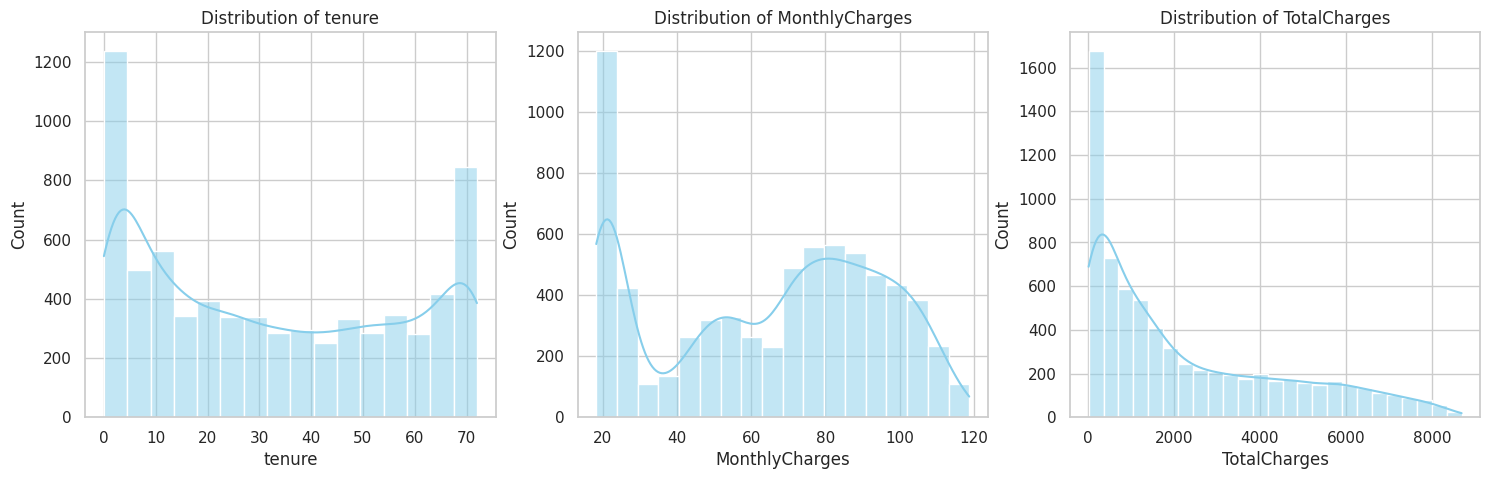

In [ ]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')

# check co-relation between features

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
# We use a copy so we don't mess up the original dataframe yet
df_analysis = df.copy()
df_analysis['Churn'] = df_analysis['Churn'].map({'Yes': 1, 'No': 0})
df_analysis['gender'] = df_analysis['gender'].map({'Male': 1, 'Female': 0})
df_analysis['Partner'] = df_analysis['Partner'].map({'Yes': 1, 'No': 0})
df_analysis['Dependents'] = df_analysis['Dependents'].map({'Yes': 1, 'No': 0})

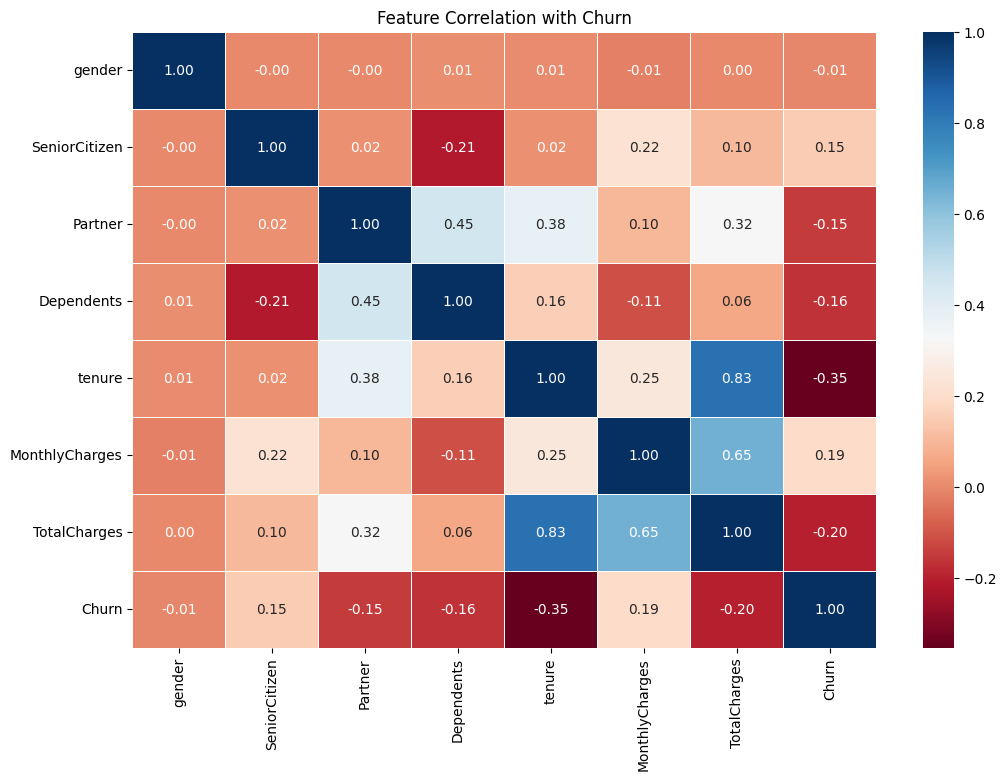

In [ ]:
# We only take the numeric columns
corr_matrix = df_analysis.select_dtypes(include=[np.number]).corr()

# code for heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation with Churn')
plt.show()

In [ ]:
print("Correlation of features with the Target (Churn):")
print(corr_matrix['Churn'].sort_values(ascending=False))

Correlation of features with the Target (Churn):
Churn             1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
gender           -0.008612
Partner          -0.150448
Dependents       -0.164221
TotalCharges     -0.199484
tenure           -0.352229
Name: Churn, dtype: float64


# data preprocessing

In [ ]:
# selected_columns = ['tenure', 'TotalCharges', 'SeniorCitizen', 'MonthlyCharges', 'Churn']
selected_columns = ['tenure', 'TotalCharges', 'SeniorCitizen', 'MonthlyCharges', 'Churn', 'Dependents', 'Partner']
datapre = df[selected_columns].copy()

In [ ]:
datapre.head(5)

,tenure,TotalCharges,SeniorCitizen,MonthlyCharges,Churn,Dependents,Partner
0,1,29.85,0,29.85,No,No,Yes
1,34,1889.50,0,56.95,No,No,No
2,2,108.15,0,53.85,Yes,No,No
3,45,1840.75,0,42.30,No,No,No
4,2,151.65,0,70.70,Yes,No,No


In [ ]:
le = LabelEncoder()

# Apply LabelEncoder to 'Dependents' and 'Partner'
for col in ['Dependents', 'Partner']:
    if col in datapre.columns:
        datapre[col] = le.fit_transform(datapre[col])

# Ensure 'Churn' is also encoded (if it's not already numeric)
datapre['Churn'] = le.fit_transform(datapre['Churn'])

In [ ]:
datapre

,tenure,TotalCharges,SeniorCitizen,MonthlyCharges,Churn,Dependents,Partner
0,1,29.85,0,29.85,0,0,1
1,34,1889.50,0,56.95,0,0,0
2,2,108.15,0,53.85,1,0,0
3,45,1840.75,0,42.30,0,0,0
4,2,151.65,0,70.70,1,0,0
...,...,...,...,...,...,...,...
7038,24,1990.50,0,84.80,0,1,1
7039,72,7362.90,0,103.20,0,1,1
7040,11,346.45,0,29.60,0,1,1
7041,4,306.60,1,74.40,1,0,1


In [ ]:
scaler = StandardScaler()
datapre[['MonthlyCharges', 'TotalCharges', 'tenure']] = scaler.fit_transform(datapre[['MonthlyCharges', 'TotalCharges', 'tenure']])

In [ ]:
print("Preprocessed Data for Training:")
print(datapre.head())
print("\nFeature Correlation with Churn in this subset:")
print(datapre.corr()['Churn'])

Preprocessed Data for Training:
     tenure  TotalCharges  SeniorCitizen  MonthlyCharges  Churn  Dependents  \
0 -1.277445     -0.994194              0       -1.160323      0           0   
1  0.066327     -0.173740              0       -0.259629      0           0   
2 -1.236724     -0.959649              0       -0.362660      1           0   
3  0.514251     -0.195248              0       -0.746535      0           0   
4 -1.236724     -0.940457              0        0.197365      1           0   

   Partner  
0        1  
1        0  
2        0  
3        0  
4        0  

Feature Correlation with Churn in this subset:
tenure           -0.352229
TotalCharges     -0.199484
SeniorCitizen     0.150889
MonthlyCharges    0.193356
Churn             1.000000
Dependents       -0.164221
Partner          -0.150448
Name: Churn, dtype: float64


# data spliting

In [ ]:
# Remove rows with NaN values before splitting data
datapre.dropna(inplace=True)

X = datapre.drop('Churn', axis=1) # The 4 columns
y = datapre['Churn']              # The target

# 2. Split the data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# 3. Initialize and Train the Model
model = LogisticRegression()
model.fit(X_train, y_train)


# Hyper parameter tuning

# param_grid_log = {
#     'C': [0.001, 0.01, 0.1, 1, 10, 100],
#     'penalty': ['l1', 'l2'],
#     'solver': ['liblinear'],
#     'max_iter': [100, 200, 500]
# }

# grid_search_logistic = GridSearchCV(
#     estimator=model,
#     param_grid=param_grid_log,
#     cv=5,
#     scoring="accuracy",
#     n_jobs=-1,
#     verbose=2
# )

# random_search_logistic = RandomizedSearchCV(
#     estimator=model,
#     param_distributions=param_grid_log,
#     n_iter=30,
#     cv=5,
#     scoring="accuracy",
#     random_state=42,
#     n_jobs=-1,
#     verbose=2
# )

# # grid_search_logistic.fit(X_train, y_train)
# random_search_logistic.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# print("Best Parameters:")
# print(random_search_logistic.best_params_)

# print("\nBest CV Score:")
# print(random_search_logistic.best_score_)

Best Parameters:
{'solver': 'liblinear', 'penalty': 'l1', 'max_iter': 200, 'C': 0.01}

Best CV Score:
0.7927111111111111


In [ ]:
# grid_pred_logistic = random_search_logistic.predict(X_test)

# print("Accuracy:",
#       accuracy_score(y_test, grid_pred_logistic))

# print(confusion_matrix(y_test, grid_pred_logistic))

# print(classification_report(y_test, grid_pred_logistic))

Accuracy: 0.7789623312011372
[[945  88]
 [223 151]]
              precision    recall  f1-score   support

           0       0.81      0.91      0.86      1033
           1       0.63      0.40      0.49       374

    accuracy                           0.78      1407
   macro avg       0.72      0.66      0.68      1407
weighted avg       0.76      0.78      0.76      1407



In [ ]:
print(X['Dependents'].value_counts())


Dependents
0    4933
1    2099
Name: count, dtype: int64


In [ ]:
y_pred = model.predict(X_test)

# 5. Evaluate the Results
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.78

Detailed Performance Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.85      1033
           1       0.61      0.44      0.51       374

    accuracy                           0.78      1407
   macro avg       0.71      0.67      0.68      1407
weighted avg       0.76      0.78      0.76      1407



cross **validation**

In [ ]:
score_lotistic = cross_val_score(model, X, y, cv=5)


In [ ]:
print(score_lotistic)
print(score_lotistic.mean())

[0.7960199  0.78606965 0.7802276  0.79231863 0.79018492]
0.7889641408887286


# knn algorithm

In [ ]:
model_knn = KNeighborsClassifier()
model_knn.fit(X_train, y_train)

# hyper parameter tuning
# model_knn = KNeighborsClassifier(n_neighbors=9)
# model_knn = KNeighborsClassifier(n_neighbors=9, weights='uniform')
# model_knn.fit(X_train, y_train)


# gridcsv method implement of hyper parameter tuing using knn
# model_knn = KNeighborsClassifier()

# params = {
#     'n_neighbors': [1, 3, 5, 7, 9]
# }

# params_2 = {
#      'n_neighbors': [3, 5, 7, 9],
#     'weights': ['uniform', 'distance'],
#     'metric': ['euclidean', 'manhattan'],
#     'p': [1, 2]
# }

# grid_knn = GridSearchCV(
#     estimator=model_knn,
#     param_grid=params_2,
#     cv=5
# )
# grid_knn.fit(X_train, y_train)


KNeighborsClassifier()

In [ ]:
print("Best K value:", grid_knn.best_params_)

# Print best accuracy
print("Best Accuracy:", grid_knn.best_score_)

Best K value: {'metric': 'manhattan', 'n_neighbors': 9, 'p': 1, 'weights': 'uniform'}
Best Accuracy: 0.7841777777777778


In [ ]:
predit_knn = model_knn.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, predit_knn):.2f}")
print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.75

Detailed Performance Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.85      1033
           1       0.61      0.44      0.51       374

    accuracy                           0.78      1407
   macro avg       0.71      0.67      0.68      1407
weighted avg       0.76      0.78      0.76      1407



**cross validation**

In [ ]:
score_knn = cross_val_score(model_knn, X, y, cv=5)

In [ ]:
print(score_knn)
print(score_knn.mean())

[0.76545842 0.76901208 0.76458037 0.77951636 0.76671408]
0.7690562630861139


# Naive bayes algorithm

In [ ]:
model_nb = GaussianNB()
model_nb.fit(X_train, y_train)

GaussianNB()

In [ ]:
predt_nb = model_nb.predict(X_test)
print(f"Model accuracy: {accuracy_score(y_test, predt_nb):.2f}")
print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred))

Model accuracy: 0.74

Detailed Performance Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.85      1033
           1       0.61      0.44      0.51       374

    accuracy                           0.78      1407
   macro avg       0.71      0.67      0.68      1407
weighted avg       0.76      0.78      0.76      1407



# decisio tree algorithm

In [ ]:
model_dt = tree.DecisionTreeClassifier()
model_dt.fit(X_train, y_train)


# model_dt = tree.DecisionTreeClassifier(criterion='gini')
# model_dt = tree.DecisionTreeClassifier(criterion='entropy')
# model_dt = tree.DecisionTreeClassifier(criterion='log_loss', splitter='best', max_depth=5, min_samples_split=4, min_samples_leaf=2, max_features='sqrt')
# model_dt.fit(X_train, y_train)

# model_dt_new = tree.DecisionTreeClassifier()
# params_dt_1 = {
#     'criterion': ['gini', 'entropy'],
#     'max_depth': [2, 3, 4, 5],
#     'min_samples_split': [2, 4, 6],
#     'min_samples_leaf': [1, 2, 3],
#     'splitter': ['best', 'random']
# }

# params_dt_2 = {
#         'criterion': ['gini', 'entropy'],
#     'splitter': ['best', 'random'],
#     'max_depth': [2, 3, 4, 5, 6],
#     'min_samples_split': [2, 4, 6, 8],
#     'min_samples_leaf': [1, 2, 3, 4],
#     'max_features': [None, 'sqrt', 'log2'],
#     'max_leaf_nodes': [None, 10, 20, 30],
#     'ccp_alpha': [0.0, 0.01, 0.02]
# }

# grid_dt_1 = GridSearchCV(
#     estimator=model_dt_new,
#     param_grid=params_dt_1,
#     cv=5
# )

# grid_dt_1.fit(X_train, y_train)


DecisionTreeClassifier()

In [ ]:
print("Best Parameters:")
print(grid_dt_1.best_params_)

# Best accuracy
print("\nBest Accuracy:")
print(grid_dt_1.best_score_)

Best Parameters:
{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}

Best Accuracy:
0.7886222222222222


In [ ]:
predt_dt = model_dt.predict(X_test)
print(f"Model accuracy: {accuracy_score(y_test, predt_dt):.2f}")
print("\nDetailed Performance Report:")
print(classification_report(y_test, predt_dt))

Model accuracy: 0.70

Detailed Performance Report:
              precision    recall  f1-score   support

           0       0.80      0.79      0.79      1033
           1       0.43      0.44      0.44       374

    accuracy                           0.70      1407
   macro avg       0.61      0.62      0.61      1407
weighted avg       0.70      0.70      0.70      1407



# support vector machine

In [ ]:
import pickle


model_svm = SVC()
model_svm.fit(X_train, y_train)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
        ("num", StandardScaler(), numerical_columns)
    ]
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("svm", SVC())
])

pipeline.fit(X_train, y_train)


# param_grid_svm = {
#     'C': [0.1, 1, 10, 100],
#     'kernel': ['linear', 'rbf'],
#     'gamma': ['scale', 'auto'],
# }

# grid_search_svm = GridSearchCV(
#     estimator=model_svm,
#     param_grid=param_grid_svm,
#     cv=5,
#     scoring='accuracy',
#     n_jobs=-1,
#     verbose=2
# )

# param_dist_svm_2 = {
#     'C': np.logspace(-3, 3, 50),
#     'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
#     'gamma': ['scale', 'auto']
# }

# random_search_svm = RandomizedSearchCV(
#     estimator=model_svm,
#     param_distributions=param_dist_svm_2,
#     n_iter=20,
#     cv=5,
#     scoring='accuracy',
#     random_state=42,
#     n_jobs=-1,
#     verbose=2
# )

# random_search_svm.fit(X_train, y_train)

# grid_search_svm.fit(X_train, y_train)


NameError: name 'categorical_columns' is not defined

In [ ]:
pickle.dump(
    svm_pipeline,
    open('churn_svm_pipeline.pkl', 'wb')
)

In [ ]:
import joblib

# Assuming 'svm_pipeline' object is already in memory from previous execution of d0bd32b7
joblib.dump(svm_pipeline, "churn_svm_pipeline.joblib")
print("SVM Pipeline saved successfully as 'churn_svm_pipeline.joblib'")

SVM Pipeline saved successfully as 'churn_svm_pipeline.joblib'


In [ ]:
# print("Best Parameters:")
# print(random_search_svm.best_params_)

# print("\nBest CV Score:")
# print(random_search_svm.best_score_)

Best Parameters:
{'kernel': 'rbf', 'gamma': 'scale', 'C': np.float64(323.745754281764)}

Best CV Score:
0.7973333333333333


In [ ]:
# grid_pred_svm = random_search_svm.predict(X_test)

# print("Accuracy:",
#       accuracy_score(y_test, grid_pred_svm))

# print(confusion_matrix(y_test, grid_pred_svm))

# print(classification_report(y_test, grid_pred_svm))

Accuracy: 0.775408670931059
[[930 103]
 [213 161]]
              precision    recall  f1-score   support

           0       0.81      0.90      0.85      1033
           1       0.61      0.43      0.50       374

    accuracy                           0.78      1407
   macro avg       0.71      0.67      0.68      1407
weighted avg       0.76      0.78      0.76      1407



In [ ]:
predt_svm = model_svm.predict(X_test)
print(f"Model accuracy: {accuracy_score(y_test, predt_svm):.2f}")
print("\nDetailed Performance Report:")
print(classification_report(y_test, predt_svm))

Model accuracy: 0.78

Detailed Performance Report:
              precision    recall  f1-score   support

           0       0.81      0.92      0.86      1033
           1       0.63      0.39      0.48       374

    accuracy                           0.78      1407
   macro avg       0.72      0.65      0.67      1407
weighted avg       0.76      0.78      0.76      1407



# to check every model using loop

In [ ]:
models_check = {
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': tree.DecisionTreeClassifier(),
    'SVM': SVC()
}

In [ ]:
result_check = []

In [ ]:
result_check

[]

# temp

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# 1. Load and expand features
df = pd.read_csv('customer.csv')
# Adding 'Contract' and 'tenure' to your original list
refined_features = ['gender', 'TotalCharges', 'SeniorCitizen', 'MonthlyCharges', 'Contract', 'tenure', 'Churn']
df = df[refined_features].copy()

# 2. Preprocessing
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

# One-Hot Encode 'Contract' (Creates Contract_One year, Contract_Two year)
df = pd.get_dummies(df, columns=['Contract'], drop_first=True)

# 3. Split
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Train Refined Model
refined_model = LogisticRegression(max_iter=1000)
refined_model.fit(X_train, y_train)

# 5. Predict and Evaluate
y_pred = refined_model.predict(X_test)
print(f"Refined Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nRefined Performance Report:")
print(classification_report(y_test, y_pred))

# Regression

In [ ]:
# df is modified in upper
df_analysis_regression = df_analysis.copy()

In [ ]:
# df_analysis_regression.head(5)
df_analysis_regression['TotalCharges'].dropna()

,TotalCharges
0,29.85
1,1889.50
2,108.15
3,1840.75
4,151.65
...,...
7038,1990.50
7039,7362.90
7040,346.45
7041,306.60


corelation of numeric only

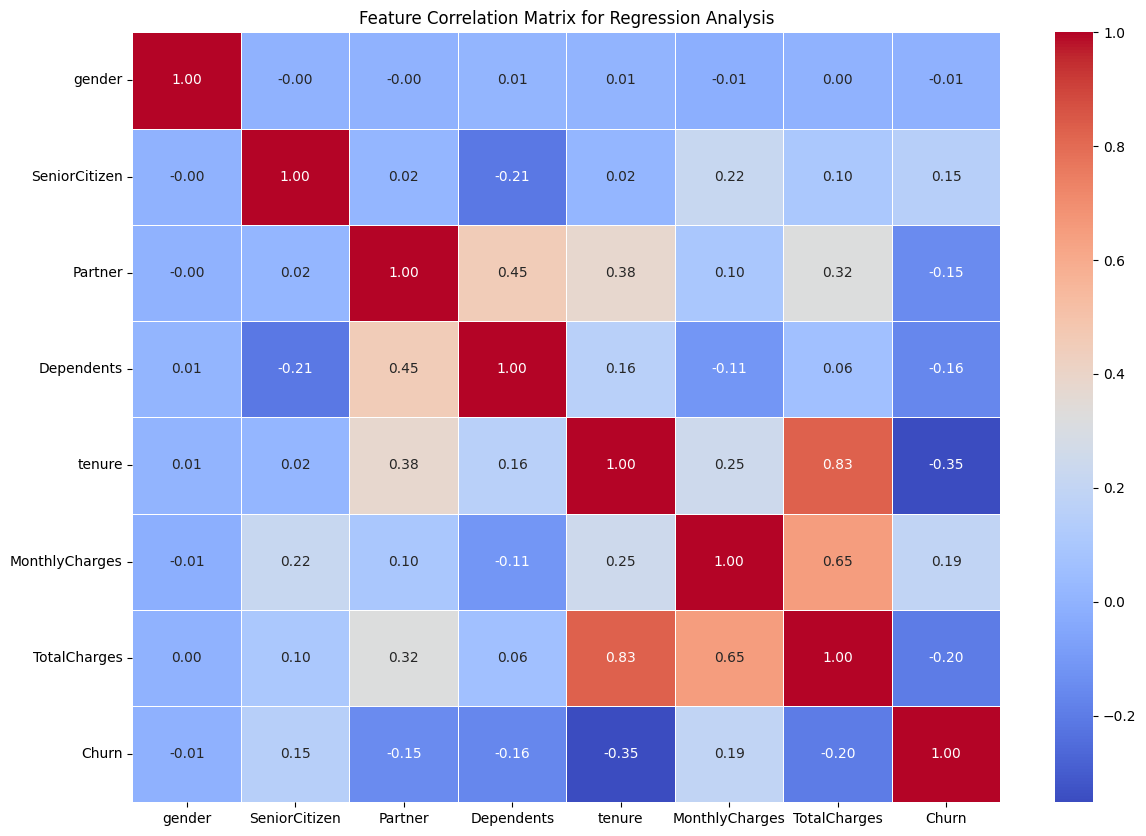

Correlation of features with MonthlyCharges (potential regression target):
MonthlyCharges    1.000000
TotalCharges      0.651065
tenure            0.247900
SeniorCitizen     0.220173
Churn             0.193356
Partner           0.096848
gender           -0.014569
Dependents       -0.113890
Name: MonthlyCharges, dtype: float64


In [ ]:
# Calculate the correlation matrix for the regression analysis
corr_mat_reg = df_analysis_regression.select_dtypes(include=[np.number]).corr()

# Display the correlation matrix, focusing on a potential regression target like 'MonthlyCharges'
plt.figure(figsize=(14, 10))
sns.heatmap(corr_mat_reg, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix for Regression Analysis')
plt.show()

print("Correlation of features with MonthlyCharges (potential regression target):")
print(corr_mat_reg['MonthlyCharges'].sort_values(ascending=False))

### Correlation including non-numeric features (after encoding)

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded_for_corr = df_analysis_regression.copy()

# Drop 'customerID' as it's just an identifier and not useful for correlation
df_encoded_for_corr = df_encoded_for_corr.drop('customerID', axis=1)

# Identify categorical columns that are not yet encoded
categorical_cols = df_encoded_for_corr.select_dtypes(include='object').columns

# Apply Label Encoding to remaining categorical columns
le = LabelEncoder()
for col in categorical_cols:
    df_encoded_for_corr[col] = le.fit_transform(df_encoded_for_corr[col])

print("DataFrame with all features numerically encoded:")
display(df_encoded_for_corr.head())


DataFrame with all features numerically encoded:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


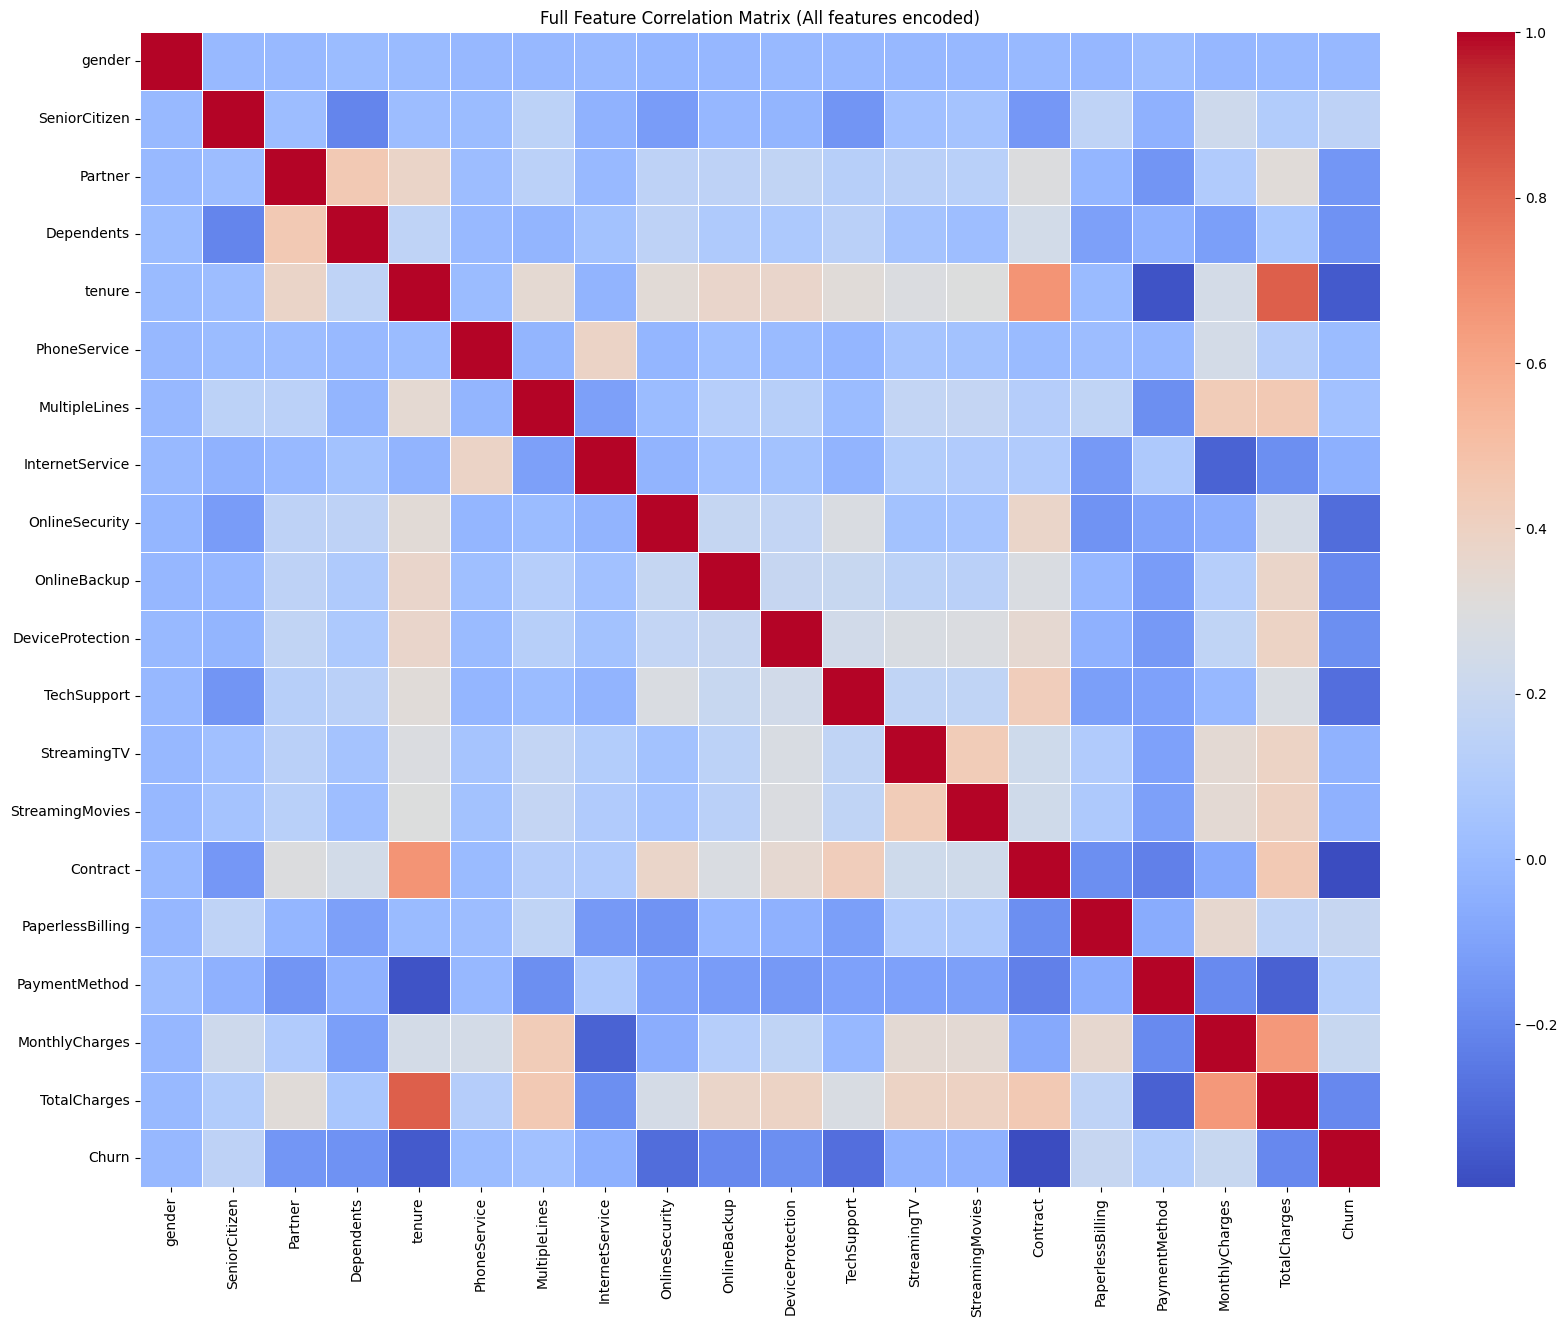

Correlation of all encoded features with MonthlyCharges:
MonthlyCharges      1.000000
TotalCharges        0.651065
MultipleLines       0.433576
PaperlessBilling    0.352150
StreamingTV         0.336706
StreamingMovies     0.335459
tenure              0.247900
PhoneService        0.247398
SeniorCitizen       0.220173
Churn               0.193356
DeviceProtection    0.163652
OnlineBackup        0.119777
Partner             0.096848
TechSupport        -0.008682
gender             -0.014569
OnlineSecurity     -0.053878
Contract           -0.074195
Dependents         -0.113890
PaymentMethod      -0.193407
InternetService    -0.323260
Name: MonthlyCharges, dtype: float64


In [ ]:
# Calculate the full correlation matrix on the encoded DataFrame
full_corr_matrix = df_encoded_for_corr.corr()

# Plot the heatmap for the full correlation matrix
plt.figure(figsize=(20, 15)) # Adjust figure size for more features
sns.heatmap(full_corr_matrix, annot=False, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Full Feature Correlation Matrix (All features encoded)')
plt.show()

# Optional: Display correlation with MonthlyCharges for the full set of features
print("Correlation of all encoded features with MonthlyCharges:")
print(full_corr_matrix['MonthlyCharges'].sort_values(ascending=False))

In [ ]:
full_corr_matrix.columns


In [ ]:
selected_col_reg = ['TotalCharges', 'MultipleLines', 'PaperlessBilling', 'StreamingMovies', 'StreamingTV', 'tenure']

scaler_reg = StandardScaler()
df_encoded_for_corr['tenure'] = scaler_reg.fit_transform(df_encoded_for_corr[['tenure']])
df_encoded_for_corr['TotalCharges'] = scaler_reg.fit_transform(df_encoded_for_corr[['TotalCharges']])

In [ ]:
# selected_col_reg = ['TotalCharges', 'MultipleLines', 'PaperlessBilling', 'StreamingMovies', 'StreamingTV', 'tenure']

In [ ]:
data_pre_reg = df_encoded_for_corr[selected_col_reg].copy()

In [ ]:
data_pre_reg.head(5)

,TotalCharges,MultipleLines,PaperlessBilling,StreamingMovies,StreamingTV,tenure
0,-0.994194,1,1,0,0,-1.277445
1,-0.173740,0,0,0,0,0.066327
2,-0.959649,0,1,0,0,-1.236724
3,-0.195248,1,0,0,0,0.514251
4,-0.940457,0,1,0,0,-1.236724


In [ ]:
data_pre_reg = df_encoded_for_corr[selected_col_reg].copy()
# Combine features and target to drop NaNs consistently
temp_df_reg = df_encoded_for_corr[selected_col_reg + ['MonthlyCharges']].copy()
temp_df_reg.dropna(inplace=True)

x_reg = temp_df_reg[selected_col_reg]
y_reg = temp_df_reg['MonthlyCharges']

In [ ]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(x_reg, y_reg, random_state=42)

In [ ]:
avg = np.mean(df_encoded_for_corr['TotalCharges'])
X_train_reg,y_train_reg.fillna(avg)

(      TotalCharges  MultipleLines  PaperlessBilling  StreamingMovies  \
 3166     -0.714239              0                 0                0   
 4333      0.285205              2                 1                0   
 1927      1.251053              2                 1                2   
 2315      0.166680              2                 1                2   
 858       1.595025              2                 0                0   
 ...            ...            ...               ...              ...   
 3778     -0.946811              2                 0                0   
 5199      1.508839              2                 1                2   
 5235     -0.661274              2                 1                0   
 5399     -0.571007              0                 0                1   
 862      -0.361686              0                 1                0   
 
       StreamingTV    tenure  
 3166            0 -0.748080  
 4333            0 -0.055834  
 1927            2  0.595692 

# linear regression

In [ ]:
model_liner_reg = LinearRegression()
model_liner_reg.fit(X_train_reg, y_train_reg)

LinearRegression()

In [ ]:
model_predt_reg = model_liner_reg.predict(X_test_reg)

In [ ]:
print("MAE:", mean_absolute_error(y_test_reg, model_predt_reg))
print("MSE:", mean_squared_error(y_test_reg, model_predt_reg))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, model_predt_reg)))
print("R2 Score:", r2_score(y_test_reg, model_predt_reg))

MAE: 12.20779842023201
MSE: 234.63023040519727
RMSE: 15.317644414373813
R2 Score: 0.7371065040128191


# Ridge regression

In [ ]:
from sklearn.linear_model import Ridge

mode_linear_ridge = Ridge()
mode_linear_ridge.fit(X_train_reg, y_train_reg)

Ridge()

In [ ]:
model_predt_ridge = mode_linear_ridge.predict(X_test_reg)

In [ ]:
print("MAE:", mean_absolute_error(y_test_reg, model_predt_ridge))
print("MSE:", mean_squared_error(y_test_reg, model_predt_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, model_predt_ridge)))
print("R2 Score:", r2_score(y_test_reg, model_predt_ridge))

MAE: 12.207313253176846
MSE: 234.63171552496212
RMSE: 15.31769289171715
R2 Score: 0.7371048399973754


# KNN

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

model_linear_knn = KNeighborsRegressor(n_neighbors=5)
model_linear_knn.fit(X_train_reg, y_train_reg)

KNeighborsRegressor()

In [ ]:
model_predt_knn = model_linear_knn.predict(X_test_reg)

In [ ]:
print("MAE:", mean_absolute_error(y_test_reg, model_predt_knn))
print("MSE:", mean_squared_error(y_test_reg, model_predt_knn))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, model_predt_knn)))
print("R2 Score:", r2_score(y_test_reg, model_predt_knn))

MAE: 2.938566552901024
MSE: 22.597018430034126
RMSE: 4.753632130280395
R2 Score: 0.9746809728494951


# LASSO

In [ ]:
from sklearn.linear_model import Lasso

model_linear_lasso = Lasso()
model_linear_lasso.fit(X_train_reg, y_train_reg)

Lasso()

In [ ]:
model_predt_lasso = model_linear_lasso.predict(X_test_reg)

In [ ]:
print("MAE:", mean_absolute_error(y_test_reg, model_predt_lasso))
print("MSE:", mean_squared_error(y_test_reg, model_predt_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, model_predt_lasso)))
print("R2 Score:", r2_score(y_test_reg, model_predt_lasso))

MAE: 12.449893767441887
MSE: 249.428727564647
RMSE: 15.793312748269345
R2 Score: 0.7205253983007143
